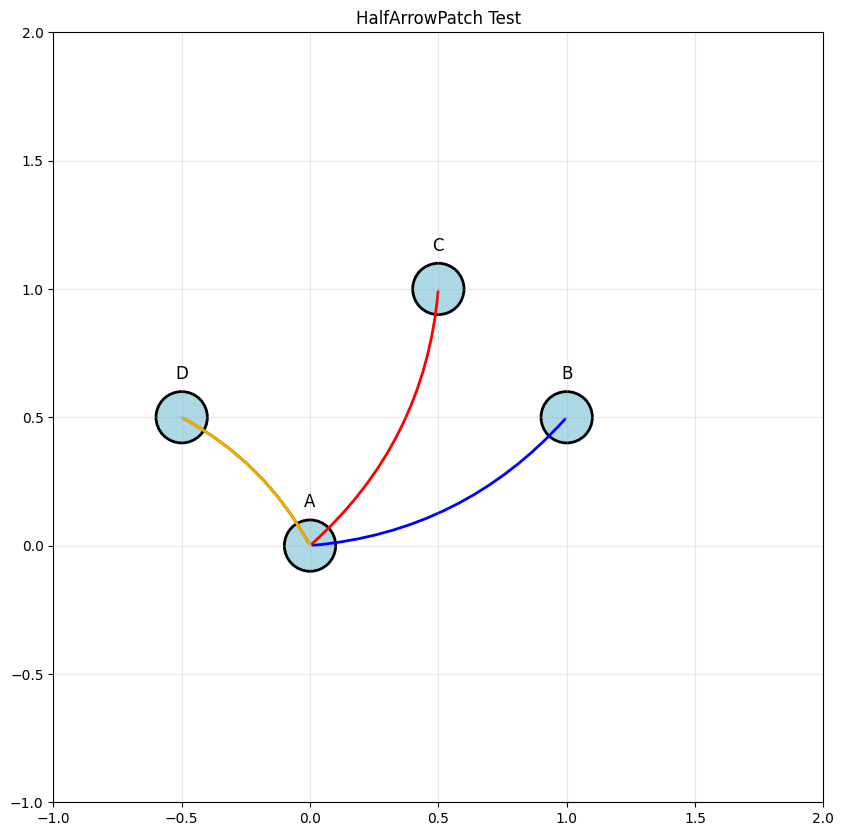

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *

class HalfArrowPatch(FancyArrowPatch):
    """
    A custom arrow patch that draws arrows with half arrowheads.
    Useful for drawing multiple parallel edges between nodes.
    """
    
    def __init__(self, posA, posB, marker='-|>', width=1, height=1, 
                 color='black', linewidth=1, curvature=0.3, 
                 arrow_linewidth=2, **kwargs):
        """
        Initialize a HalfArrowPatch.
        
        Parameters:
        -----------
        posA, posB : tuples
            Starting and ending positions (x, y)
        marker : str
            Arrow style ('-|>' for right half, '|\\' for left half, etc.)
        width, height : float
            Width and height of the arrowhead
        color : str or tuple
            Arrow color
        linewidth : float
            Width of the arrow shaft
        curvature : float
            Curvature of the arrow (0 = straight, >0 = curved)
        arrow_linewidth : float
            Width of the arrowhead lines
        **kwargs : additional arguments for FancyArrowPatch
        """
        # Store parameters
        self.marker = marker
        self.arrow_width = width
        self.arrow_height = height
        self.arrow_linewidth = arrow_linewidth
        self.curvature = curvature
        
        # Initialize the parent class
        super().__init__(posA, posB, 
                        connectionstyle=f"arc3,rad={curvature}",
                        arrowstyle='-',  # Start with no arrowhead, we'll draw it manually
                        color=color,
                        linewidth=linewidth,
                        **kwargs)
        
        self._color = color
        self._posA = np.array(posA)
        self._posB = np.array(posB)
        
    def draw(self, renderer):
        """Override draw method to add custom half arrowhead."""
        # Draw the curved line first
        super().draw(renderer)
        
        # Get the transformed points
        trans = self.get_transform()
        posA_trans = trans.transform(self._posA)
        posB_trans = trans.transform(self._posB)
        
        # Calculate the direction at the end of the curve
        # For curved arrows, we need the tangent at the endpoint
        if self.curvature != 0:
            # For curved arrows, calculate tangent at endpoint
            C, R = self._get_circle_center()
            if C is not None:
                # Vector from center to endpoint
                v = posB_trans - C
                # Tangent is perpendicular to radius
                tangent = np.array([-v[1], v[0]])
                tangent = tangent / np.linalg.norm(tangent)
            else:
                # Fallback to straight line direction
                tangent = posB_trans - posA_trans
                tangent = tangent / np.linalg.norm(tangent)
        else:
            # Straight line - direction is from start to end
            tangent = posB_trans - posA_trans
            tangent = tangent / np.linalg.norm(tangent)
        
        # Perpendicular vector (90 degrees rotation)
        perp = np.array([-tangent[1], tangent[0]])
        
        # Calculate arrowhead points based on marker style
        arrowhead_center = posB_trans
        
        if self.marker == '-|>' or self.marker == '|>':
            # Right half arrowhead (pointing to the right of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|\\' or self.marker == '<|':
            # Left half arrowhead (pointing to the left of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|<':
            # Half arrowhead on the other side (for bidirectional)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        else:
            # Default full arrowhead
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center
            ]
        
        # Create the arrowhead patch
        if len(points) >= 3:
            # Create path for the filled arrowhead
            verts = points
            codes = [Path.MOVETO] + [Path.LINETO] * (len(points)-2) + [Path.CLOSEPOLY]
            
            path = Path(verts, codes)
            patch = PathPatch(path, facecolor=self._color, 
                            edgecolor=self._color, 
                            linewidth=self.arrow_linewidth,
                            transform=transforms.IdentityTransform(),
                            zorder=self.zorder+1)
            
            # Draw the arrowhead
            patch.draw(renderer)
    
    def _get_circle_center(self):
        """Calculate the center of the circle for curved arrows."""
        try:
            A = self._posA
            B = self._posB
            rad = self.curvature
            
            # Calculate the center of the arc
            M = (A + B) / 2
            d = B - A
            L = np.linalg.norm(d)
            
            if L == 0:
                return None, None
                
            n = np.array([-d[1], d[0]]) / L
            h = rad * L / 2
            R = (L**2 / 4 + h**2) / (2 * h)
            C = M + n * (R - L**2 / (8 * h))
            
            return C, R
        except:
            return None, None


def test_half_arrow():
    """Test function to demonstrate HalfArrowPatch usage."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create some test positions
    pos = {
        'A': np.array([0, 0]),
        'B': np.array([1, 0.5]),
        'C': np.array([0.5, 1]),
        'D': np.array([-0.5, 0.5])
    }
    
    # Draw nodes
    for node, p in pos.items():
        circle = plt.Circle(p, 0.1, color='lightblue', ec='black', lw=2)
        ax.add_patch(circle)
        ax.text(p[0], p[1]+0.15, node, ha='center', fontsize=12)
    
    # Test different arrow styles
    # Right half arrow
    arrow1 = HalfArrowPatch(
        pos['A'], pos['B'],
        marker='-|>',
        width=0.2, height=0.3,
        color='blue',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow1)
    
    # Left half arrow
    arrow2 = HalfArrowPatch(
        pos['A'], pos['C'],
        marker='|\\',
        width=0.2, height=0.3,
        color='red',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow2)
    
    # Double arrows (parallel)
    arrow3 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='-|>',
        width=0.2, height=0.3,
        color='green',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    ax.add_patch(arrow3)
    
    arrow4 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='|\\',
        width=0.2, height=0.3,
        color='orange',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    # Adjust offset manually
    arrow4._posA = arrow4._posA + np.array([0.05, 0.05])
    arrow4._posB = arrow4._posB + np.array([0.05, 0.05])
    ax.add_patch(arrow4)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('HalfArrowPatch Test')
    
    plt.show()


if __name__ == "__main__":
    test_half_arrow()
    



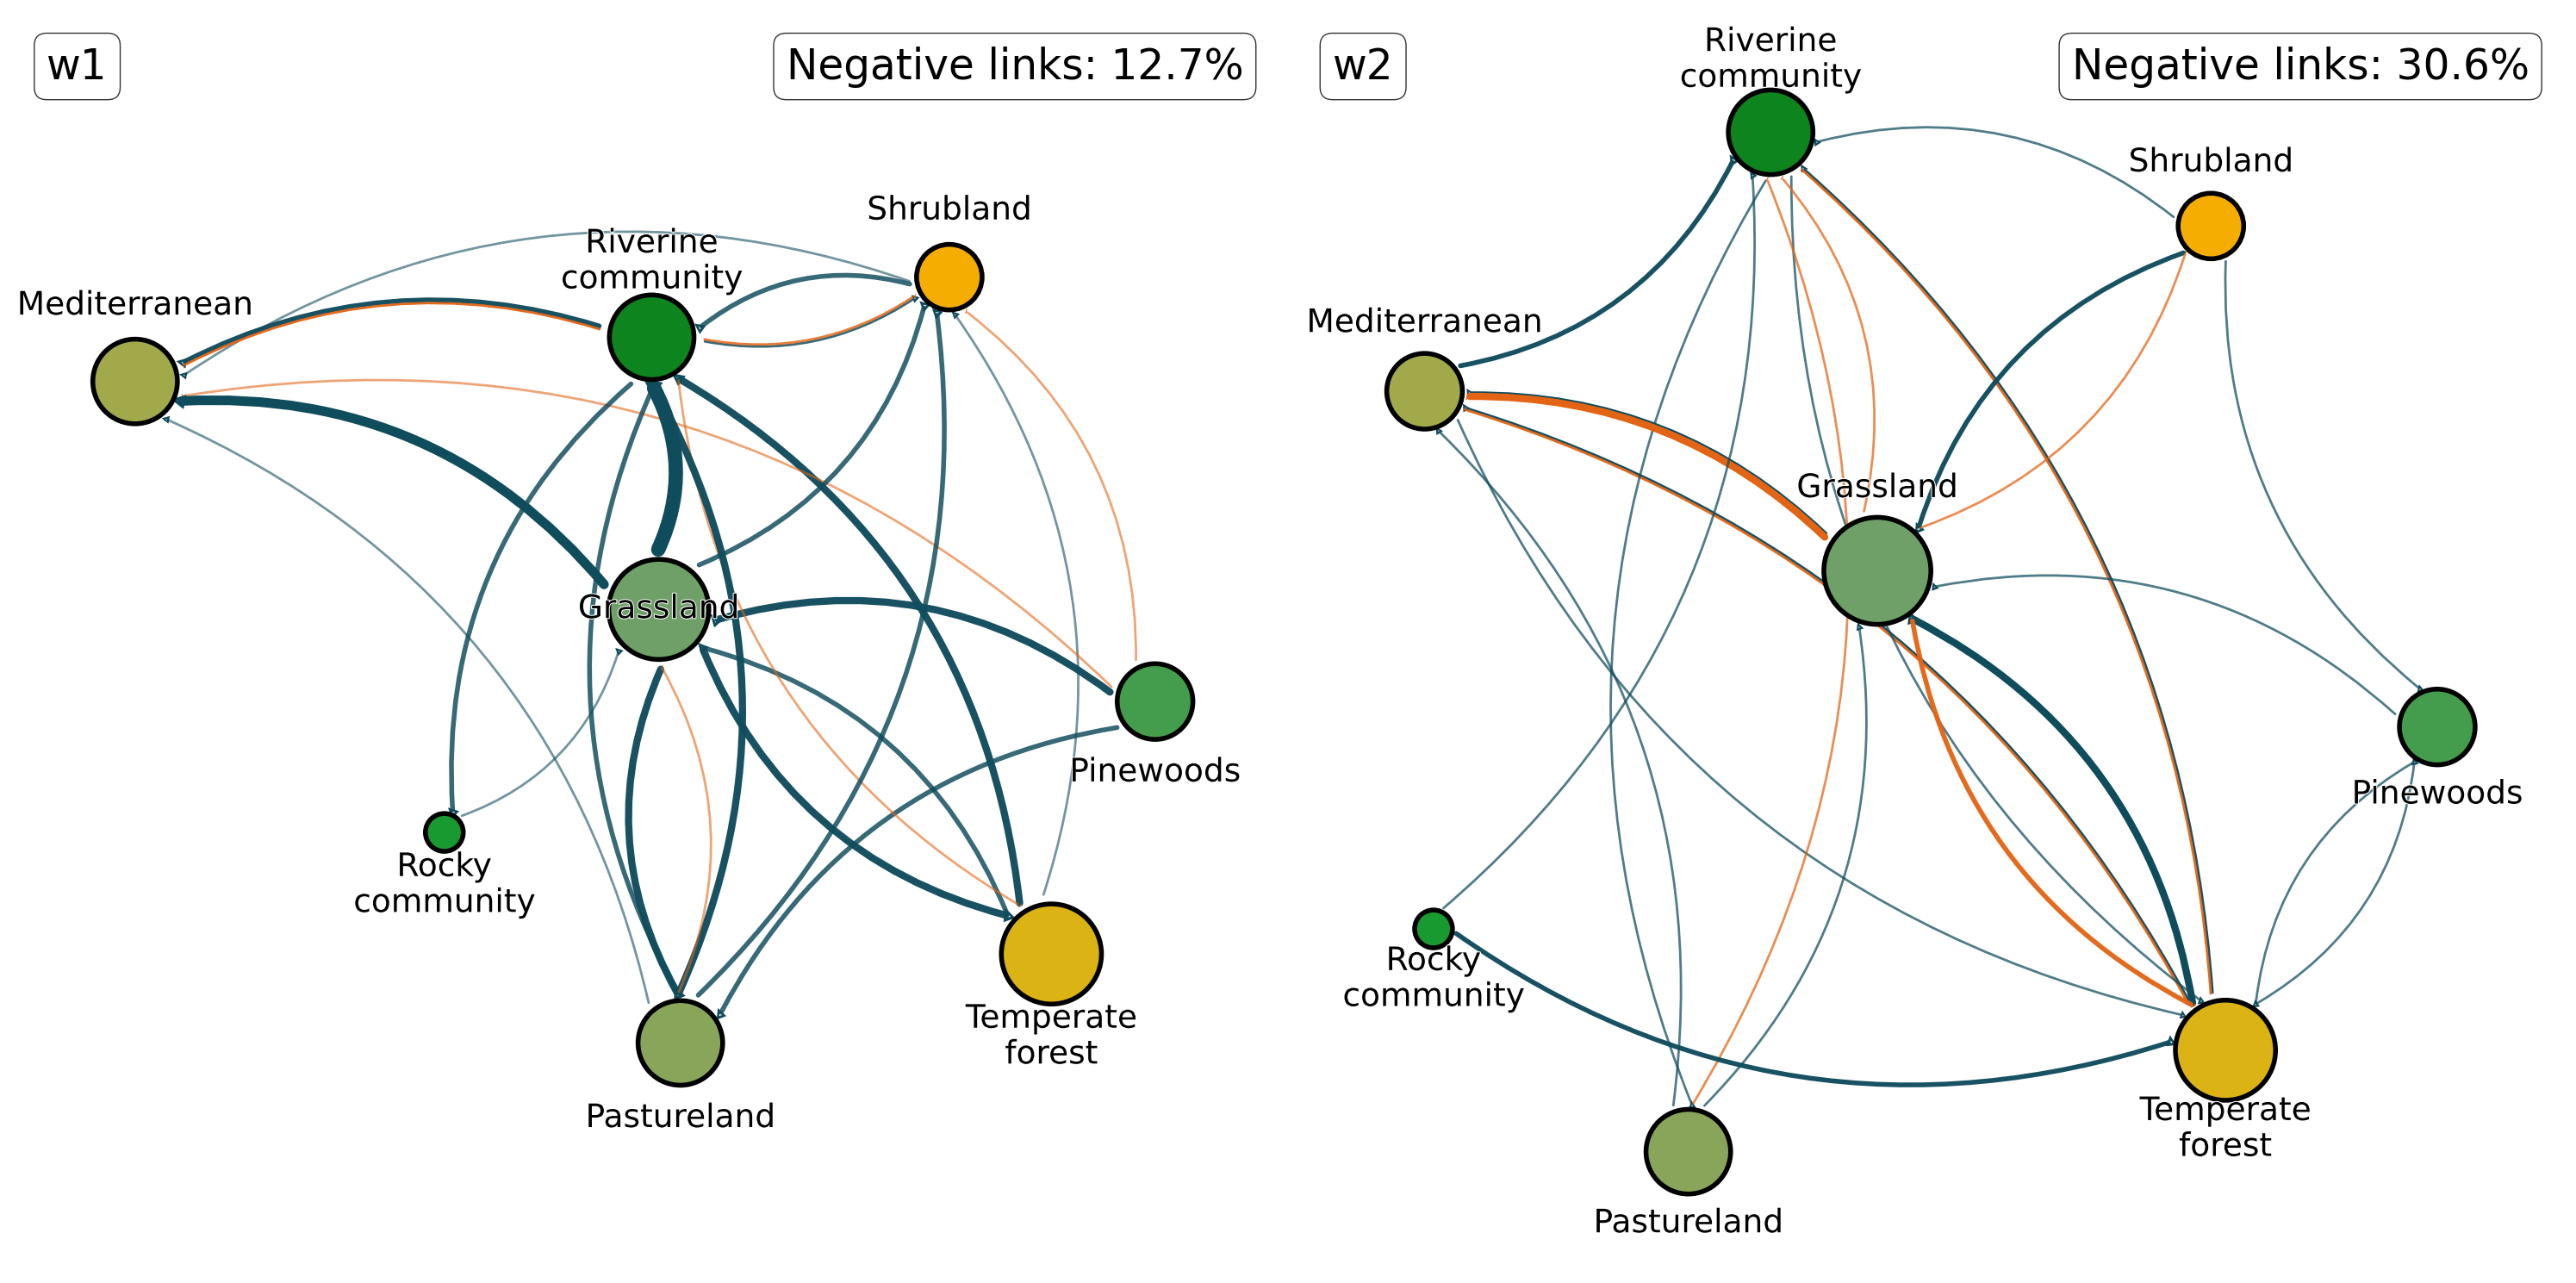

In [6]:
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

# Importar las funciones personalizadas
from lib.halfarrowpatch import *  # Asegúrate de que esta importación funciona

# =====================================================
# FUNCIONES AUXILIARES (copiadas de tu código)
# =====================================================

def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) / 2
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L / 2
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, 
                    offset=0.0, node_radius_u=0.05, node_radius_v=0.05, 
                    arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

def sequential_custom_generator():
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows
    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

# =====================================================
# CONFIG
# =====================================================

windows_names = ["w1", "w2"]

POS_COLOR = "#0F4C5C"  # Azul verdoso para positivas
NEG_COLOR = "#E36414"  # Naranja para negativas

# =====================================================
# COMUNIDADES
# =====================================================

groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# =====================================================
# MAPEO DE COMUNIDADES A ÍNDICES Y ETIQUETAS
# =====================================================

# Crear mapeo inverso de comunidad a índice numérico
community_to_index = {
    'grassland': 0,
    'mediterranean': 1,
    'pastureland': 2,
    'pinewoods': 3,
    'riverine community': 4,
    'rocky community': 5,
    'shrubland': 6,
    'temperate forest': 7
}

# Mapeo de índice a etiqueta (igual que en el original)
labels = {
    7: 'Temperate\nforest',
    3: 'Pinewoods',
    6: 'Shrubland',
    4: 'Riverine\ncommunity',
    1: 'Mediterranean',
    2: 'Pastureland',
    0: 'Grassland',
    5: 'Rocky\ncommunity'
}

# Orden para las posiciones iniciales (igual que en el original)
order = {
    'Temperate\nforest': 1,
    'Pinewoods': 2,
    'Shrubland': 3,
    'Riverine\ncommunity': 4,
    'Mediterranean': 5,
    'Rocky\ncommunity': 6,
    'Pastureland': 7
}

# Mapeo inverso de comunidad a etiqueta
community_to_label = {
    'temperate forest': 'Temperate\nforest',
    'pinewoods': 'Pinewoods',
    'shrubland': 'Shrubland',
    'riverine community': 'Riverine\ncommunity',
    'mediterranean': 'Mediterranean',
    'rocky community': 'Rocky\ncommunity',
    'pastureland': 'Pastureland',
    'grassland': 'Grassland'
}

# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(30, 15))

for idx, window_name in enumerate(windows_names):
    ax = axes[idx]

    with open(f"trama_{window_name}.pkl", "rb") as f:
        data = pickle.load(f)

    sig = np.array(data["matriz_significancia"])
    species_order = data["especies"]

    # =================================================
    # RED ESPECIES
    # =================================================

    G_species = nx.DiGraph()

    for sp in species_order:
        if sp in species_to_community:
            G_species.add_node(sp,
                community=species_to_community[sp])

    n = len(species_order)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            sp1 = species_order[i]
            sp2 = species_order[j]

            if sp1 not in species_to_community or sp2 not in species_to_community:
                continue

            sign = sig[i, j]

            if sign == 0:
                continue

            G_species.add_edge(sp1, sp2, sign=sign)

    # =================================================
    # CONTAR ESPECIES POR COMUNIDAD
    # =================================================

    community_counts = defaultdict(int)

    for node in G_species.nodes():
        comm = G_species.nodes[node]["community"]
        community_counts[comm] += 1

    # =================================================
    # RED COMUNIDADES
    # =================================================

    G = nx.MultiDiGraph()

    for comm, count in community_counts.items():
        G.add_node(comm, size=count)

    # Contar edges positivos y negativos entre comunidades
    edge_counts = defaultdict(lambda: {"pos": 0, "neg": 0})

    for u, v, data in G_species.edges(data=True):
        cu = G_species.nodes[u]["community"]
        cv = G_species.nodes[v]["community"]

        if cu == cv:
            continue

        if data["sign"] == 1:
            edge_counts[(cu, cv)]["pos"] += 1
        else:
            edge_counts[(cu, cv)]["neg"] += 1

    # Añadir edges a la red de comunidades
    for (u, v), counts in edge_counts.items():
        if counts["pos"] > 0:
            G.add_edge(u, v, color=POS_COLOR, weight=counts["pos"] * 2)
        if counts["neg"] > 0:
            G.add_edge(u, v, color=NEG_COLOR, weight=counts["neg"] * 2)

    # Eliminar edges con peso cero (por si acaso)
    for u, v, key, weight in G.copy().edges(data="weight", keys=True):
        if weight == 0:
            G.remove_edge(u, v, key)

    # =================================================
    # POSICIONES INICIALES (como en el original)
    # =================================================

    # Obtener lista de comunidades presentes
    communities_present = list(G.nodes())
    
    # Configurar posiciones iniciales
    initial_pos = {}
    
    # Grassland en el centro (índice 0)
    grassland_comm = None
    for comm in communities_present:
        if community_to_index[comm] == 0:
            grassland_comm = comm
            initial_pos[comm] = np.array([0.0, 0.0])
            break

    # Calcular posiciones para las demás comunidades
    if grassland_comm:
        N = len(communities_present)
        angle_step = 2 * np.pi / (N - 1)
        other_comms = [c for c in communities_present if c != grassland_comm]
        
        for comm in other_comms:
            idx = community_to_index[comm]
            label = labels[idx]
            # Asegurarse de que la etiqueta existe en order
            if label in order:
                angle = angle_step * (order[label] - 2)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])
            else:
                # Si no está en el orden, asignar posición aleatoria en el círculo
                angle = np.random.uniform(0, 2*np.pi)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])

    # Aplicar spring layout con posiciones iniciales
    pos = nx.spring_layout(
        G,
        weight='weight',
        seed=1,
        pos=initial_pos,
        iterations=2
    )

    # =================================================
    # NODOS
    # =================================================

    node_sizes = {n: G.nodes[n]['size'] * 1000 for n in G.nodes()}
    
    # Generar colores para las comunidades
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1 / 700000
    scale = 0.00094  # escala para offsets

    # =================================================
    # ARISTAS (usando HalfArrowPatch)
    # =================================================

    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(
        sum(edge['weight'] for edge in edges)
        for edges in edge_groups.values()
    ) if edge_groups else 1

    # Dibujar aristas agrupadas por par de nodos
    for (u, v), edges in edge_groups.items():
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4 * total_width / max_total_weight), 1)

        if n == 1:
            # Una sola arista
            data = edges[0]
            # Usar arrowstyle según el color
            if data["color"] == POS_COLOR:
                arrow_style = '|/'  # Para positivas
            else:
                arrow_style = '|\\'  # Para negativas
            
            add_curved_edge(
                ax, pos, u, v,
                color=data["color"],
                weight=data["weight"],
                rad=0.25,
                angle=0,
                offset=0.0,
                node_radius_u=node_sizes[u] * node_size_scale,
                node_radius_v=node_sizes[v] * node_size_scale,
                arrowstyle=arrow_style,
                zorder=-1,
                alpha=alpha
            )

        elif n == 2:
            # Dos aristas: una positiva y una negativa
            # Separar por color para identificar positiva y negativa
            pos_edges = [e for e in edges if e["color"] == POS_COLOR]
            neg_edges = [e for e in edges if e["color"] == NEG_COLOR]
            
            sorted_edges = []
            if pos_edges:
                sorted_edges.append(pos_edges[0])
            if neg_edges:
                sorted_edges.append(neg_edges[0])
            
            if len(sorted_edges) == 2:
                w_0 = sorted_edges[0]["weight"]
                w_1 = sorted_edges[1]["weight"]
                
                # Calcular offsets para que queden paralelas
                offset = (w_0 + w_1 / 1.0) * scale
                
                np.random.seed(0)
                rad = np.random.uniform(0.15, 0.25)
                
                # Primera arista (normalmente la positiva)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[0]["color"],
                    weight=w_0,
                    rad=rad,
                    angle=0,
                    offset=-offset - 0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|/',  # Para la primera
                    zorder=-1,
                    alpha=alpha
                )
                
                # Segunda arista (normalmente la negativa)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[1]["color"],
                    weight=w_1,
                    rad=rad,
                    angle=0,
                    offset=-0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|\\',  # Para la segunda
                    zorder=-1,
                    alpha=alpha
                )
            else:
                # Si por alguna razón solo hay un tipo de edge, dibujar como caso n=1
                for data in edges:
                    arrow_style = '|/' if data["color"] == POS_COLOR else '|\\'
                    add_curved_edge(
                        ax, pos, u, v,
                        color=data["color"],
                        weight=data["weight"],
                        rad=0.25,
                        angle=0,
                        offset=0.0,
                        node_radius_u=node_sizes[u] * node_size_scale,
                        node_radius_v=node_sizes[v] * node_size_scale,
                        arrowstyle=arrow_style,
                        zorder=-1,
                        alpha=alpha
                    )

    # =================================================
    # DIBUJAR NODOS
    # =================================================

    nx.draw_networkx_nodes(
        G, pos,
        node_color=[community_colors[node] for node in G.nodes()],
        ax=ax,
        node_size=[node_sizes[n] for n in G.nodes()],
        edgecolors="black",
        linewidths=4
    )

    # =================================================
    # ETIQUETAS CON OFFSET (como en el original)
    # =================================================

    label_pos = {}
    for n in G.nodes():
        # Calcular offset para la etiqueta
        if pos[n][1] > 0.1:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        elif pos[n][1] < -0.1:
            offset = np.array([0, -np.sqrt(node_sizes[n]) * 0.001 - 0.06])
        elif pos[n][0] > 0.2:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        else:
            offset = np.array([0, 0.0])
            
        label_pos[n] = pos[n] + offset

    # Crear diccionario de etiquetas
    node_labels = {}
    for n in G.nodes():
        idx = community_to_index[n]
        node_labels[n] = labels[idx]

    texts = nx.draw_networkx_labels(
        G, label_pos,
        ax=ax,
        labels=node_labels,
        font_size=27,
        font_color='black'
    )

    for text in texts.values():
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground='white'),
            path_effects.Normal()
        ])

    # =================================================
    # AJUSTAR LÍMITES DEL GRÁFICO
    # =================================================

    # Hacer el gráfico cuadrado
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    width = xlim[1] - xlim[0]
    height = ylim[1] - ylim[0]
    
    if width > height:
        center_y = (ylim[0] + ylim[1]) / 2
        ax.set_ylim(center_y - width/2, center_y + width/2)
    else:
        center_x = (xlim[0] + xlim[1]) / 2
        ax.set_xlim(center_x - height/2, center_x + height/2)
    
    # Añadir margen
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)

    # =================================================
    # TEXTO INFORMATIVO
    # =================================================

    # Calcular porcentaje de links negativos (para la red de especies)
    negative_links = len([e for e in G_species.edges(data=True) if e[2]['sign'] < 0])
    total_links = G_species.number_of_edges()
    negative_percentage = negative_links / total_links if total_links > 0 else 0

    # Añadir título con el nombre de la ventana temporal
    ax.text(0.03, 0.97, window_name,
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Añadir porcentaje de links negativos
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axis("off")

plt.tight_layout()
plt.show()

In [105]:
import numpy as np

import pickle

with open("results_w1_wio.pkl", "rb") as f:
    data = pickle.load(f)

especies = data["especies"]
mat_sig = data["matriz_significancia"]

A_dir = mat_sig  # tu matriz dirigida
n = len(A_dir)

A = np.zeros((n, n))  # matriz no dirigida final

for i in range(n):
    for j in range(i+1, n):
        a_ij = A_dir[i][j]
        a_ji = A_dir[j][i]

        if a_ij == 0 and a_ji == 0:
            continue

        # conflicto → eliminar
        if a_ij * a_ji == -1:
            continue

        # mismo signo o uno solo → mantener
        sign = a_ij if a_ij != 0 else a_ji
        A[i, j] = sign
        A[j, i] = sign


A_abs = np.abs(A)

from scipy.linalg import expm

expA = expm(A)
expA_abs = expm(A_abs)

k_local = np.diag(expA) / np.diag(expA_abs)
idx_pinus = especies.index("Pinus")
k_pinus = k_local[idx_pinus]
SC = np.diag(expA_abs)
SC_total = np.sum(SC)
SC_pinus = SC[idx_pinus]
peso_pinus = SC_pinus / SC_total*100
K_global = np.sum(SC * k_local) / np.sum(SC)

print(f"K_local de Pinus: {k_pinus:.4f}")
print(f"K_global: {K_global:.4f}")
print(f"SC de Pinus: {peso_pinus:.4f}")

n = A.shape[0]

pos = 0
neg = 0

for i in range(n):
    for j in range(i+1, n):
        if A[i, j] == 1:
            pos += 1
        elif A[i, j] == -1:
            neg += 1

print("Enlaces positivos:", pos)
print("Enlaces negativos:", neg)
print("Porcentaje negativo:", neg / (pos + neg) * 100)

import numpy as np

print(np.mean(k_local))
print(np.std(k_local))

K_local de Pinus: 0.8480
K_global: 0.7111
SC de Pinus: 0.2223
Enlaces positivos: 148
Enlaces negativos: 52
Porcentaje negativo: 26.0
0.6841222554643749
0.18327045129032266


Text(0, 0.5, 'k_v')

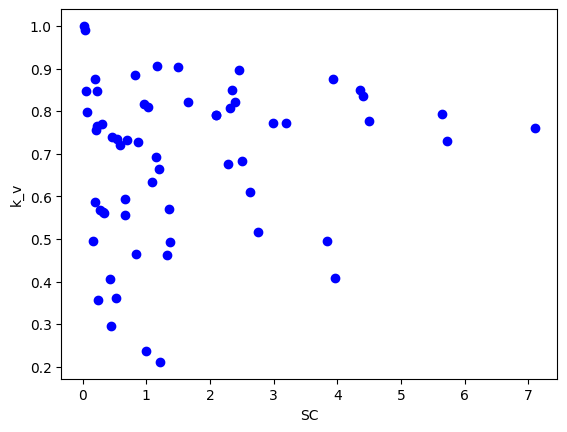

In [106]:
import matplotlib.pyplot as plt

plt.scatter(SC/SC_total*100, k_local, color='blue')
plt.xlabel("SC")
plt.ylabel("k_v")

(array([24., 14.,  4.,  8.,  2.,  3.,  3.,  1.,  1.,  1.]),
 array([0.0215747 , 0.72979711, 1.43801953, 2.14624195, 2.85446437,
        3.56268679, 4.27090921, 4.97913162, 5.68735404, 6.39557646,
        7.10379888]),
 <BarContainer object of 10 artists>)

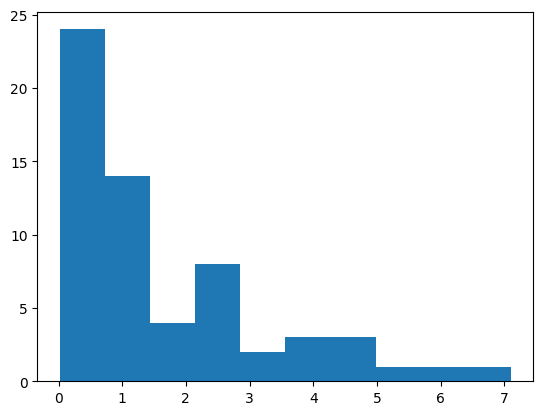

In [42]:
plt.hist(SC/SC_total*100, bins=10)

In [107]:
import numpy as np

import pickle

with open("results_w2_wio.pkl", "rb") as f:
    data = pickle.load(f)

especies = data["especies"]
mat_sig = data["matriz_significancia"]

A_dir = mat_sig  # tu matriz dirigida
n = len(A_dir)

A = np.zeros((n, n))  # matriz no dirigida final

for i in range(n):
    for j in range(i+1, n):
        a_ij = A_dir[i][j]
        a_ji = A_dir[j][i]

        if a_ij == 0 and a_ji == 0:
            continue

        # conflicto → eliminar
        if a_ij * a_ji == -1:
            continue

        # mismo signo o uno solo → mantener
        sign = a_ij if a_ij != 0 else a_ji
        A[i, j] = sign
        A[j, i] = sign


A_abs = np.abs(A)

from scipy.linalg import expm

expA = expm(A)
expA_abs = expm(A_abs)

k_local = np.diag(expA) / np.diag(expA_abs)
idx_pinus = especies.index("Pinus")
k_pinus = k_local[idx_pinus]
SC = np.diag(expA_abs)
SC_total = np.sum(SC)
SC_pinus = SC[idx_pinus]
peso_pinus = SC_pinus / SC_total*100
K_global = np.sum(SC * k_local) / np.sum(SC)

print(f"K_local de Pinus: {k_pinus:.4f}")
print(f"K_global: {K_global:.4f}")
print(f"SC de Pinus: {peso_pinus:.4f}")

n = A.shape[0]

pos = 0
neg = 0

for i in range(n):
    for j in range(i+1, n):
        if A[i, j] == 1:
            pos += 1
        elif A[i, j] == -1:
            neg += 1

print("Enlaces positivos:", pos)
print("Enlaces negativos:", neg)
print("Porcentaje negativo:", neg / (pos + neg) * 100)
import numpy as np

print(np.mean(k_local))
print(np.std(k_local))

K_local de Pinus: 0.9984
K_global: 0.7130
SC de Pinus: 0.5242
Enlaces positivos: 51
Enlaces negativos: 35
Porcentaje negativo: 40.69767441860465
0.8172641051681256
0.17910650655741223


Text(0, 0.5, 'k_v')

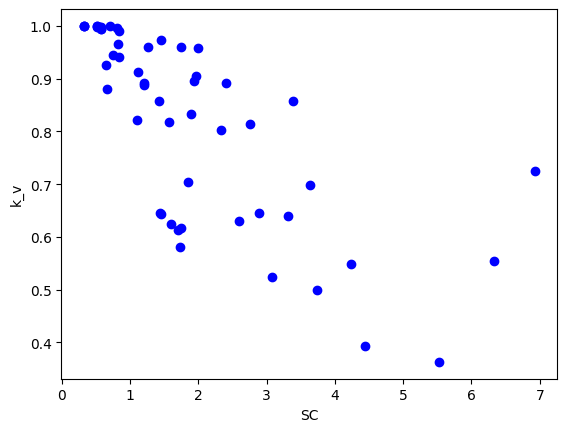

In [108]:
import matplotlib.pyplot as plt

plt.scatter(SC/SC_total*100, k_local, color='blue')
plt.xlabel("SC")
plt.ylabel("k_v")

In [43]:
import numpy as np

import pickle

with open("results_w3_wio.pkl", "rb") as f:
    data = pickle.load(f)

especies = data["especies"]
mat_sig = data["matriz_significancia"]

A_dir = mat_sig  # tu matriz dirigida
n = len(A_dir)

A = np.zeros((n, n))  # matriz no dirigida final

for i in range(n):
    for j in range(i+1, n):
        a_ij = A_dir[i][j]
        a_ji = A_dir[j][i]

        if a_ij == 0 and a_ji == 0:
            continue

        # conflicto → eliminar
        if a_ij * a_ji == -1:
            continue

        # mismo signo o uno solo → mantener
        sign = a_ij if a_ij != 0 else a_ji
        A[i, j] = sign
        A[j, i] = sign


A_abs = np.abs(A)

from scipy.linalg import expm

expA = expm(A)
expA_abs = expm(A_abs)

k_local = np.diag(expA) / np.diag(expA_abs)
idx_pinus = especies.index("Pinus")
k_pinus = k_local[idx_pinus]
SC = np.diag(expA_abs)
SC_total = np.sum(SC)
SC_pinus = SC[idx_pinus]
peso_pinus = SC_pinus / SC_total*100
K_global = np.sum(SC * k_local) / np.sum(SC)

print(f"K_local de Pinus: {k_pinus:.4f}")
print(f"K_global: {K_global:.4f}")
print(f"SC de Pinus: {peso_pinus:.4f}")

n = A.shape[0]

pos = 0
neg = 0

for i in range(n):
    for j in range(i+1, n):
        if A[i, j] == 1:
            pos += 1
        elif A[i, j] == -1:
            neg += 1

print("Enlaces positivos:", pos)
print("Enlaces negativos:", neg)
print("Porcentaje negativo:", neg / (pos + neg) * 100)
import numpy as np

print(np.mean(k_local))
print(np.std(k_local))

K_local de Pinus: 0.3097
K_global: 0.6526
SC de Pinus: 7.0848
Enlaces positivos: 68
Enlaces negativos: 33
Porcentaje negativo: 32.67326732673268
0.841617987167566
0.2196507620117208


In [35]:
idx_sorted = np.argsort(k_local)
for i in idx_sorted[:10]:
    print(especies[i], k_local[i], SC[i]/SC_total*100)

Olea 0.23177859747820612 5.196986078167389
Cardueae 0.253188967858611 8.39394900426145
Pinus 0.30968769798221035 7.0847984562504625
Fraxinus 0.3168509753811587 3.270668864837331
Cichorioideae 0.374686122747057 3.1951611782081586
Salix 0.40486594341096205 4.148075982068797
Galium 0.49919360380074845 6.839055297003309
Helianthemum 0.5128859600728503 1.8750641530024523
Rubiaceae 0.5186266947722856 2.320710354884849
Plantago 0.5612641623994656 1.8336837341270043


Text(0, 0.5, 'k_v')

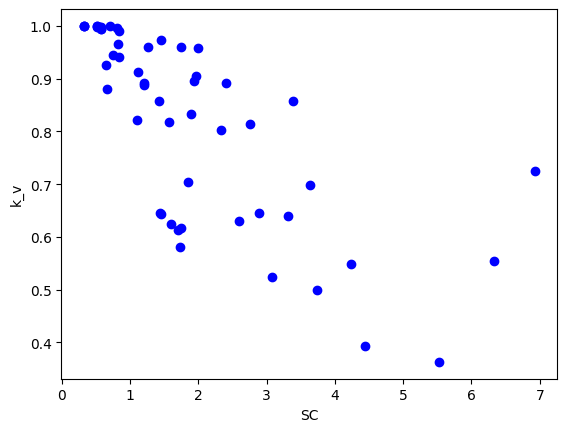

In [109]:
import matplotlib.pyplot as plt

plt.scatter(SC/SC_total*100, k_local, color='blue')
plt.xlabel("SC")
plt.ylabel("k_v")

(array([31., 16.,  4.,  3.,  2.,  0.,  1.,  0.,  2.,  1.]),
 array([0.27014167, 1.0825224 , 1.89490314, 2.70728387, 3.5196646 ,
        4.33204534, 5.14442607, 5.9568068 , 6.76918754, 7.58156827,
        8.393949  ]),
 <BarContainer object of 10 artists>)

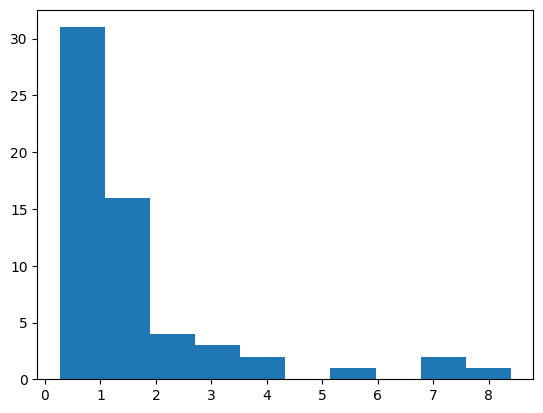

In [44]:
plt.hist(SC/SC_total*100, bins=10)

In [67]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# --- funciones ---
def construir_A(mat_sig):
    n = len(mat_sig)
    A = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            a_ij = mat_sig[i][j]
            a_ji = mat_sig[j][i]

            if a_ij == 0 and a_ji == 0:
                continue

            if a_ij * a_ji == -1:
                continue

            sign = a_ij if a_ij != 0 else a_ji
            A[i, j] = sign
            A[j, i] = sign

    return A

def calcular_SC(A):
    A_abs = np.abs(A)
    expA_abs = expm(A_abs)
    SC = np.diag(expA_abs)
    return SC


def calcular_k_local(A):
    A_abs = np.abs(A)
    expA = expm(A)
    expA_abs = expm(A_abs)
    
    k_local = np.diag(expA) / np.diag(expA_abs)
    return np.nan_to_num(k_local, nan=np.nan)


# --- cargar datos ---
files = [
    "results_w1_wio.pkl",
    "results_w2_wio.pkl",
    "results_w3_wio.pkl"
]

datos = []

for f in files:
    with open(f, "rb") as file:
        data = pickle.load(file)
    datos.append(data)

# --- conjunto global de especies ---
todas_especies = sorted(set(
    sp for d in datos for sp in d["especies"]
))

idx_global = {sp: i for i, sp in enumerate(todas_especies)}

# --- matriz de k_all con NaN ---
k_all = np.full((3, len(todas_especies)), np.nan)
SC_all = np.full((3, len(todas_especies)), np.nan)


for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A = construir_A(mat_sig)
    
    k_local = calcular_k_local(A)
    SC = calcular_SC(A)
    SC_percent = 100 * SC / np.nansum(SC)
    
    for i, sp in enumerate(especies):
        j = idx_global[sp]
        k_all[t, j] = k_local[i]
        SC_all[t, j] = SC_percent[i]


# --- seleccionar 10 peores en W3 (ignorando NaN) ---
# k_w3 = k_all[2]

# valid_idx = np.where(~np.isnan(k_w3))[0]
# idx_peores = valid_idx[np.argsort(k_w3[valid_idx])[:10]]

# especies_peores = [todas_especies[i] for i in idx_peores]

# print("Especies con menor balance en W3:")
# for sp in especies_peores:
#     print(sp)

# # --- plot ---
# plt.figure(figsize=(8,6))

# for i in idx_peores:
#     plt.plot([1,2,3], k_all[:, i], marker='o', label=todas_especies[i])
#     #plt.plot(..., linestyle='--', alpha=0.5)


# plt.xlabel("Ventana temporal")
# plt.ylabel("k_v")
# plt.title("Evolución temporal (10 especies peor balance en W3)")

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

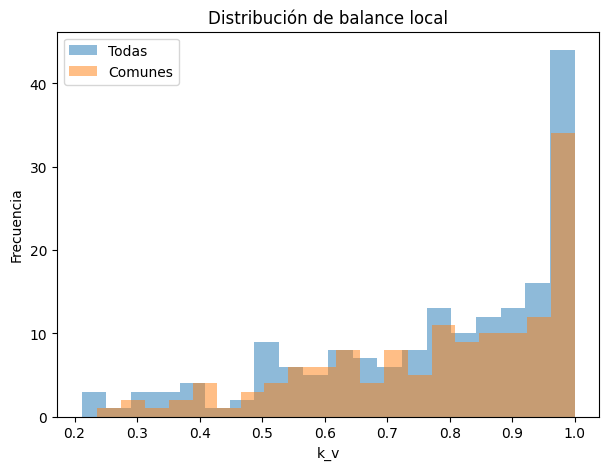

In [57]:
import matplotlib.pyplot as plt

k_all_flat = k_all.flatten()
k_all_flat = k_all_flat[~np.isnan(k_all_flat)]

idx_comunes = [idx_global[sp] for sp in especies_comunes]
k_comunes = k_all[:, idx_comunes].flatten()
k_comunes = k_comunes[~np.isnan(k_comunes)]

plt.figure(figsize=(7,5))
plt.hist(k_all_flat, bins=20, alpha=0.5, label="Todas")
plt.hist(k_comunes, bins=20, alpha=0.5, label="Comunes")

plt.xlabel("k_v")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de balance local")

plt.show()

In [59]:
# especies por ventana
sets_especies = [set(d["especies"]) for d in datos]

# intersección → presentes en todas
especies_comunes = set.intersection(*sets_especies)

# unión → todas
todas_especies = set.union(*sets_especies)

# intermitentes
especies_intermitentes = todas_especies - especies_comunes

print("Especies siempre presentes:", len(especies_comunes))
print("Especies intermitentes:", len(especies_intermitentes))

idx_inter = [idx_global[sp] for sp in especies_intermitentes]

k_inter = k_all[:, idx_inter].flatten()
k_inter = k_inter[~np.isnan(k_inter)]

print("Media k_v comunes:", np.nanmean(k_comunes))
print("Media k_v intermitentes:", np.nanmean(k_inter))

Especies siempre presentes: 47
Especies intermitentes: 26
Media k_v comunes: 0.7855963654369708
Media k_v intermitentes: 0.7507408139599583


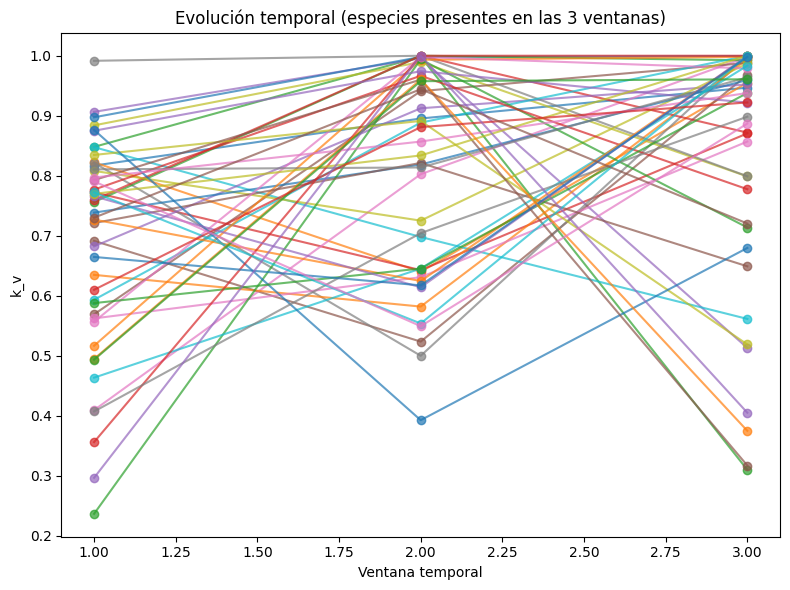

In [53]:
plt.figure(figsize=(8,6))

for sp in especies_comunes:
    i = idx_global[sp]
    plt.plot([1,2,3], k_all[:, i], marker='o', alpha=0.7)

plt.xlabel("Ventana temporal")
plt.ylabel("k_v")
plt.title("Evolución temporal (especies presentes en las 3 ventanas)")

plt.tight_layout()
plt.show()

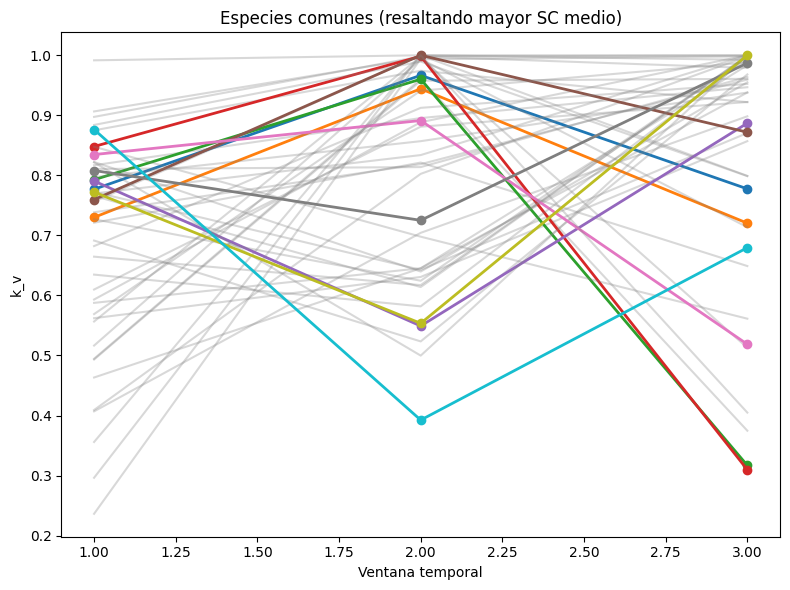

In [74]:
SC_mean = np.nanmean(SC_all, axis=0)
idx_top_sc = np.argsort(SC_mean)[-15:]

top_species_mask = np.zeros(len(todas_especies), dtype=bool)
top_species_mask[idx_top_sc] = True
SC_top_total = np.nansum(SC_all[:, top_species_mask], axis=1)


plt.figure(figsize=(8,6))

for i in range(len(todas_especies)):
    if np.isnan(k_all[:, i]).any():
        continue
    
    if i in idx_top_sc:
        plt.plot([1,2,3], k_all[:, i], marker='o', linewidth=2)
    else:
        plt.plot([1,2,3], k_all[:, i], color='gray', alpha=0.3)

plt.xlabel("Ventana temporal")
plt.ylabel("k_v")
plt.xticks(None)
plt.title("Especies comunes (resaltando mayor SC medio)")

plt.tight_layout()
plt.show()

In [103]:
presentes_todas = ~np.isnan(k_all).any(axis=0)

SC_mean = np.nanmean(SC_all, axis=0)

# solo especies completas
SC_mean_valid = SC_mean[presentes_todas]

idx_valid = np.where(presentes_todas)[0]

# top 8 dentro de las completas
top_local_idx = np.argsort(SC_mean_valid)[-15:]

idx_top_sc = idx_valid[top_local_idx]
idx_top_sc = idx_top_sc[np.argsort(SC_mean[idx_top_sc])[::-1]]

SC_mean = np.nanmean(SC_all, axis=0)
idx_top_sc = np.argsort(SC_mean)[-15:]

top_species_mask = np.zeros(len(todas_especies), dtype=bool)
top_species_mask[idx_top_sc] = True
SC_top_total = np.nansum(SC_all[:, top_species_mask], axis=1)


labels = {
    i: f"{todas_especies[i]} ({SC_mean[i]:.2f}%)"
    for i in idx_top_sc
}


In [116]:
presentes_todas = ~np.isnan(k_all).any(axis=0)

SC_mean = np.nanmean(SC_all, axis=0)

SC_mean_valid = SC_mean[presentes_todas]
idx_valid = np.where(presentes_todas)[0]

top_local_idx = np.argsort(SC_mean_valid)[-5:]
idx_top_sc = idx_valid[top_local_idx]

# ordenar de mayor a menor SC
idx_top_sc = idx_top_sc[np.argsort(SC_mean[idx_top_sc])[::-1]]

top_species_mask = np.isin(np.arange(len(todas_especies)), idx_top_sc)

SC_top_total = np.nansum(SC_all[:, top_species_mask], axis=1)
labels = {
    i: f"{todas_especies[i]} ({SC_mean[i]:.2f}%)"
    for i in idx_top_sc
}

In [147]:
t_sel = 0  # red 2

presentes_todas = ~np.isnan(k_all).any(axis=0)

SC_sel = SC_all[t_sel]

# filtrar especies completas
SC_sel_valid = SC_sel[presentes_todas]
idx_valid = np.where(presentes_todas)[0]

# top 15 en esa red
top_local_idx = np.argsort(SC_sel_valid)[-5:]
idx_top_sc = idx_valid[top_local_idx]

# ordenar
idx_top_sc = idx_top_sc[np.argsort(SC_sel[idx_top_sc])[::-1]]

labels = {
    i: f"{todas_especies[i]} ({SC_sel[i]:.2f}%)"
    for i in idx_top_sc
}

top_species_mask = np.isin(np.arange(len(todas_especies)), idx_top_sc)
SC_top_total = np.nansum(SC_all[:, top_species_mask], axis=1)

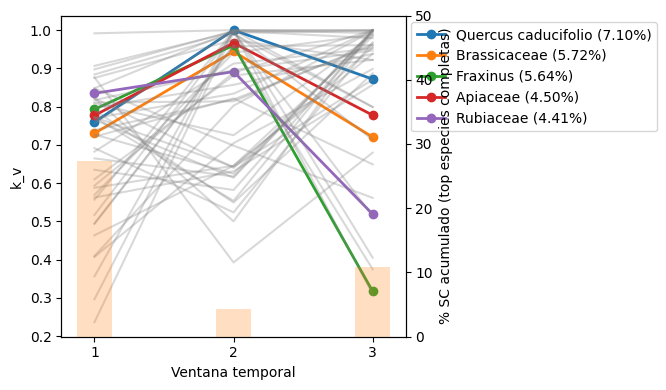

In [151]:
fig, ax1 = plt.subplots(figsize=(10,4))
ax2 = ax1.twinx()

# --- líneas ordenadas ---
for i in idx_top_sc:
    ax1.plot(
        [1,2,3],
        k_all[:, i],
        marker='o',
        linewidth=2,
        label=labels[i]
    )

# resto en gris
for i in range(len(todas_especies)):
    if i in idx_top_sc:
        continue
    if np.isnan(k_all[:, i]).any():
        continue
    
    ax1.plot([1,2,3], k_all[:, i], color='gray', alpha=0.3)

# --- barras SC acumulada (solo especies válidas) ---
ax2.bar([1,2,3], SC_top_total, width=0.25, alpha=0.25, color='tab:orange')

ax1.set_xlabel("Ventana temporal")
ax1.set_ylabel("k_v")
ax2.set_ylabel("% SC acumulado (top especies completas)")

ax1.set_xticks([1,2,3])
#ax1.set_title("Especies top (ordenadas por % SC medio)")

ax1.legend(fontsize=10, bbox_to_anchor=(1.75, 1))

ax2.set_ylim(0, 50)
plt.tight_layout()
plt.show()

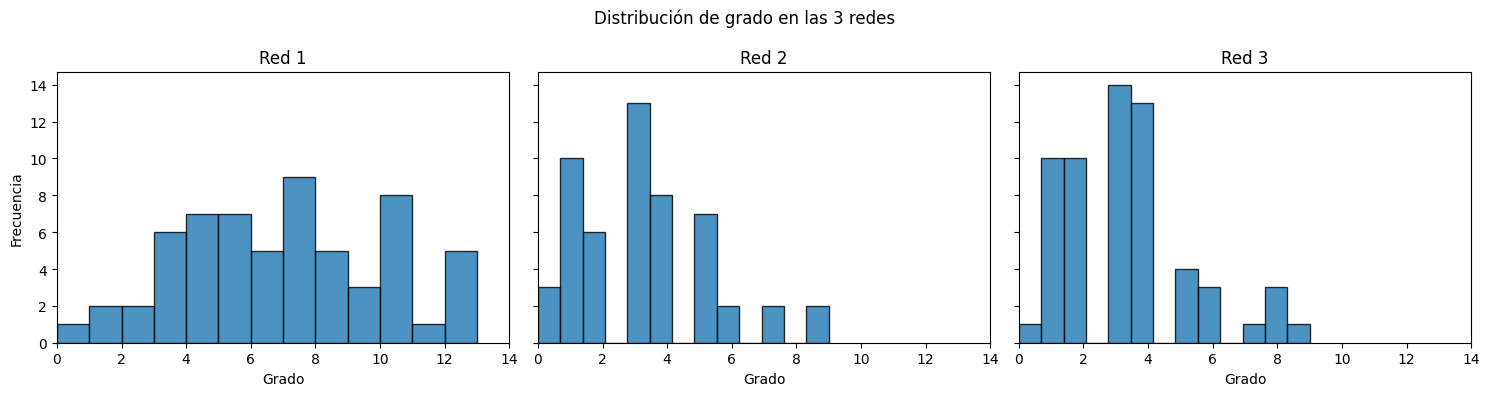

In [96]:
def calcular_grado(A):
    return np.sum(np.abs(A), axis=1)

grados_all = []

for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A = construir_A(mat_sig)
    
    grados = calcular_grado(A)
    grados_all.append(grados)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

bins = 13  # ajusta si quieres más resolución

for t in range(3):
    axes[t].hist(grados_all[t], bins=bins, alpha=0.8, edgecolor='black')
    
    axes[t].set_title(f"Red {t+1}")
    axes[t].set_xlabel("Grado")
    axes[t].set_xlim(0, np.max(grados_all[0]) + 1)
    
axes[0].set_ylabel("Frecuencia")

plt.suptitle("Distribución de grado en las 3 redes")
plt.tight_layout()
plt.show()

In [6]:
df_original.head()

,cal BP,Alchemilla,Chenopodiaceae,Artemisia,Cichoroideae,Asteroideae,Carduus,Asteraceae,Vernonia,Polygonum,...,Lamiaceae,Cerealia,Plantago,Planceolata,Poaceae,Rumex,Solanum,Urticaceae,Ricinus,Saussurea
0,3.709000,0.497209,17.885223,2.813531,0.000691,0.005494,0.000304,2.651289,0.000013,0.000029,...,0.826846,0.000056,0.000532,0.000080,68.019374,0.000049,0.000005,0.000040,0.000005,0.000171
1,3.696599,0.693804,22.190395,0.981039,0.845885,3.777682,-0.003261,5.712253,-0.000134,-0.000309,...,0.354682,-0.000602,-0.005704,-0.000862,56.412193,-0.000524,-0.000056,-0.000456,-0.000052,0.169994
2,3.684197,0.586922,14.541684,0.051146,0.875582,2.980895,-0.000936,5.181144,-0.000038,-0.000089,...,0.612175,-0.000173,-0.001637,-0.000247,63.625000,-0.000150,-0.000016,-0.000236,-0.000015,0.142349
3,3.671796,0.144879,16.365537,2.125026,0.164990,2.129956,0.000502,1.965553,0.000021,0.000048,...,0.120297,0.000093,0.000879,0.000133,65.999711,0.000081,0.000009,0.000638,0.000008,0.005170
4,3.659395,0.461935,21.710864,3.053837,1.098253,0.777424,-0.000273,2.787899,-0.000013,-0.000026,...,0.253529,-0.000050,-0.000478,-0.000072,59.404882,-0.000044,-0.000005,-0.003640,-0.000004,0.210412


In [10]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    #"w1": (0, 56),
    #"w2": (57, 149),
    "w3": (150, 249),
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w3
Tamaño ventana: 100 observaciones
Especies válidas en ventana: 67

Generando bootstrap...
Significativos: 163 (3.69%)
Cola baja: 61 (37.42%)
Cola alta: 102

Proceso terminado correctamente.


In [9]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    "w1": (0, 56),
    #"w2": (57, 149),
    #"w3": (150, 249),
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w1
Tamaño ventana: 57 observaciones
Especies válidas en ventana: 43

Generando bootstrap...
Significativos: 80 (4.43%)
Cola baja: 39 (48.75%)
Cola alta: 41

Proceso terminado correctamente.


In [8]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    #"w1": (0, 56),
    #"w2": (57, 149)
    "w3": (150, 249)
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w3
Tamaño ventana: 100 observaciones
Especies válidas en ventana: 67

Generando bootstrap...
Significativos: 148 (3.35%)
Cola baja: 65 (43.92%)
Cola alta: 83

Proceso terminado correctamente.
